In [1]:
import pandas as pd
import numpy as np
from models import cmre, nmre, ndee, ocsvm
from models_ds import cmre_ds_2
from plots import plot_appendix, plot_main_paper
import copy
import pickle
import matplotlib.pyplot as plt

In [2]:
RESULTS_DIR = 'sensitivity_analysis_tyler_vanderweele_results_2'

In [3]:
def generate_sgc_datasets(true_upcoding_rate, true_downcoding_rate,
                          sa_normal,
                          sa_untrustworthy,
                          te
                          ):

    # Load dataset
    df = pd.read_excel('./datasets/default_of_credit_card_clients.xls', skiprows=1)
    df = df.sample(frac=1).reset_index(drop=True)

    # Drop rows that are not needed
    df = df[['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']]

    # Convert sex to binary variable
    df['SEX'] = df['SEX'] - 1

    # Convert marriage to binary variable
    df['MARRIAGE'] = np.where(df['MARRIAGE'] > 1, 1, 0)

    # Convert education to binary variable
    df['EDUCATION'] = np.where(df['EDUCATION'] > 2, 1, 0)

    # Min-max scale the data
    df['AGE'] = (df['AGE'] - df['AGE'].min()) / (df['AGE'].max() - df['AGE'].min())

    # Use marriage as selection bias
    agent_prob = 0.05  + (1-df['MARRIAGE'])*0.4
    df['AGENT'] = np.random.binomial(1, agent_prob, len(df))
    
    # Generate employment variable
    employment_prob = 0.05 \
                    + df['EDUCATION']*0.05 \
                    + df['MARRIAGE']*df['SEX']*0.3 \
                    + np.square(df['AGE'])*0.1 \
                    + df['AGENT'] * sa_untrustworthy + (1-df['AGENT'])*sa_normal
    df['EMPLOYMENT'] = np.random.binomial(1, employment_prob, len(df))

    # Generate default variable
    # muskaan comment: this is Y, te is beta(x) in the paper
    default_prob = 0.05 \
                    + df['EDUCATION']*0.05 \
                    + df['MARRIAGE']*df['SEX']*0.3 \
                    + np.square(df['AGE'])*0.1 \
                    + df['EMPLOYMENT'] * te
    df['DEFAULT'] = np.random.binomial(1, default_prob, len(df))

    # Strategically misreport the dataset (misreported employment status)
    prob_required_for_upcoding_rate = ((employment_prob / (1-true_upcoding_rate)) - employment_prob) / (1 - employment_prob)
    prob_required_for_downcoding_rate = (((1 - employment_prob) / (1-true_downcoding_rate)) - (1 - employment_prob)) / employment_prob
    # prob_required_for_downcoding_rate = pd.Series(np.where(prob_required_for_downcoding_rate_raw > 1, 1, prob_required_for_downcoding_rate_raw))
    # sometimes the value of prob_required_for_downcoding_rate_raw ends up exceeding 1, so we cap it at 1 to prevent issues

    df['EMPLOYMENT'] = (df['EMPLOYMENT'] + df['AGENT']*(1-df['EMPLOYMENT']) * np.random.binomial(1, prob_required_for_upcoding_rate,  len(df))
                        - df['EMPLOYMENT']*(1-df['AGENT']) * np.random.binomial(1, prob_required_for_downcoding_rate, len(df)))

    return df

# Results for semi-synthetic loan experiments

In [4]:
num_sims = 100
causal_effect = 0.2 # true causal effect of X* on Y
true_upcoding_rate = 0.20
true_downcoding_rate = 0.10
# Dataframes to keep track of results
cmre_ds_sensitivity_analysis_df = pd.DataFrame(columns=['sim_num', 'ab', 'd_plus', 'conf interval covered true val'])

alpha_beta_products = [0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

# Perform a few simulations for each method
for sim in range(num_sims):
    # Set the random seed
    np.random.seed(sim)

    # Generate dataset for simulation
    df = generate_sgc_datasets(true_upcoding_rate, true_downcoding_rate, 0.1, 0.3, causal_effect)

    normal_dataset = df[df['AGENT'] == 0]
    strategic_dataset = df[df['AGENT'] == 1]
    
    # Get misreporting rates and keep track of results
    # we let the unobserved confounder U be age
    estimated_mr, delta_star = cmre_ds_2('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE'], normal_dataset, strategic_dataset) # the data stitching version of CMRE

    for alpha_beta_product in alpha_beta_products:
        # So your x-axis iirc, is |\alpha \times \beta|.
        # For a two-sided confidence interval, you could have first estimate d+ (using \alpha \times beta)
        # and d- (similar to d+, but instead use -1 \times alpha \times \beta in the equation for d).
        # Therefore, your confidence interval would be (estimated MR + d-, estimated MR + d+)

        d_plus = alpha_beta_product / (alpha_beta_product + delta_star) * (1 - estimated_mr)
        d_minus = (- alpha_beta_product) / (- alpha_beta_product + delta_star) * (1 - estimated_mr)
        
        # test whether the confidence interval contains the true upcoding rate
        conf_interval_contains_true_val = (true_upcoding_rate >= estimated_mr - d_minus) and (true_upcoding_rate <= estimated_mr + d_plus)

        cmre_ds_sensitivity_analysis_df.loc[len(cmre_ds_sensitivity_analysis_df)] = [sim, alpha_beta_product, d_plus, conf_interval_contains_true_val]

In [5]:
# Save info
with open(f'{RESULTS_DIR}/cmre_ds_sensitivity_analysis.pkl', 'wb') as f:
    pickle.dump(cmre_ds_sensitivity_analysis_df, f)

# Create plots

In [6]:
# Load lists
with open(f'{RESULTS_DIR}/cmre_ds_sensitivity_analysis.pkl', 'rb') as f:
    cmre_ds_sensitivity_analysis_df = pickle.load(f)

In [7]:
# cmre_ds_sensitivity_analysis_df[cmre_ds_sensitivity_analysis_df["ab"] == 0.3]

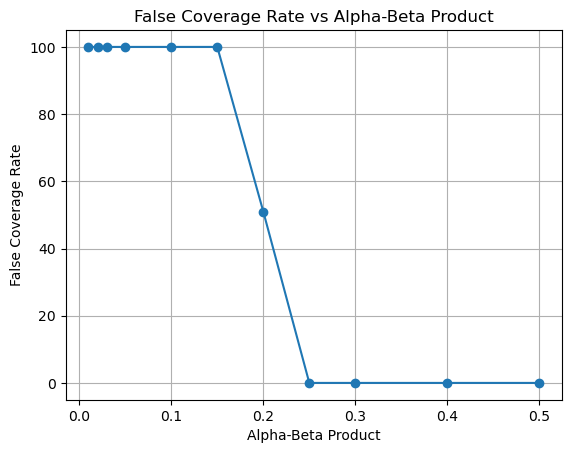

In [8]:
# compute percent of False per ab
false_pct = (
    cmre_ds_sensitivity_analysis_df.groupby("ab")["conf interval covered true val"]
      .apply(lambda x: (~x).mean() * 100)
      .reset_index(name="percent_false")
)

# plot
plt.figure()
plt.plot(false_pct["ab"], false_pct["percent_false"], marker="o")
plt.xlabel("Alpha-Beta Product")
plt.ylabel("False Coverage Rate")
plt.title("False Coverage Rate vs Alpha-Beta Product")
plt.grid(True)

# plt.show()
plt.savefig(f'{RESULTS_DIR}/cmre_ds_sensitivity_analysis.pdf', dpi=600, bbox_inches='tight')